# K VECINOS MÁS CERCANOS (K NEAREST NEIGHBOURS-KNN)   


## El modelo.   

**K-Vecinos Más Cercanos** es uno de los modelos predictivos más sencillos que hay. No realiza suposiciones matemáticas y no exige ningún tipo de maquinaria pesada. Lo único que requiere es:    

    ■ Una cierta noción de distancia.   

    ■ La suposición de que los puntos que están cerca uno de otro son similares.   

La mayor parte de las técnicas que se usan en Machine Learning tienen en cuenta el conjunto de datos como un todo para descubrir patrones en los datos. **K-Vecinos Más Cercanos**, por otra parte, descuida de forma consciente mucha información, ya que la predicción para cada nuevo punto ***depende únicamente del grupo de puntos más cercanos a él***.
Es más, probablemente **K-Vecinos Más Cercanos** no ayudará a comprender los elementos causantes del fenómeno que se esté observando. Predecir mi voto basándose en el de mis vecinos no dice mucho sobre las causas que me hacen votar como lo hago, mientras que otro modelo alternativo que prediga mi voto basándose en (por ejemplo) mis ingresos y mi estado civil sí podría ayudar a averiguarlas.   

En situaciones generales, tenemos puntos de datos y el correspondiente conjunto de etiquetas. Las etiquetas podrían ser True y False, indicando que cada entrada satisface una determinada condición, como “¿es spam?”, “¿es venenoso?” o “¿sería divertido de ver?”. O bien podrían ser categorías, como calificaciones de películas (G, PG, PG-13, R, NC-17). También podrían ser los nombres de los candidatos presidenciales o incluso lenguajes de programación favoritos.   

En nuestro caso, los puntos de datos serán vectores, lo que significa que podemos utilizar la función distance del capítulo 4. Supongamos que elegimos un número k, como 3 o 5. Entonces, cuando queremos clasificar un punto de datos nuevo, encontramos los k puntos más cercanos etiquetados y les dejamos votar en el nuevo resultado.    

Para ello, necesitaremos una función que cuente votos. Una posibilidad es:

In [ ]:
from typing import List
from collections import Counter
def raw_majority_vote(labels: List[str]) -> str: # Función simple sin manejo de empates
    votes = Counter(labels)
    winner, _ = votes.most_common(1)[0]
    return winner

assert raw_majority_vote(["a", "b", "c", "b"]) == "b"

Pero esto no hace nada inteligente con los empates. Por ejemplo, imaginemos que estamos calificando películas y las cinco más cercanas están clasificadas como G, G, PG, PG y R. Vemos que tanto G como PG tienen dos votos. En ese caso, tenemos varias opciones:    

- Elegir uno de los ganadores aleatoriamente.
- Ponderar los votos por distancia y elegir el ganador resultante.
- Reducir k hasta encontrar un ganador único.    

Si implementamos la tercera opción:

In [ ]:
def majority_vote(labels: List[str]) -> str: # Función recursiva para manejar empates
    # Se supone que las etiquetas están ordenadas de más cercana a más lejana.
    vote_counts = Counter(labels)
    winner, winner_count = vote_counts.most_common(1)[0]
    num_winners = len([count
                for count in vote_counts.values()
                        if count == winner_count])
    if num_winners == 1:
            return winner # ganador único, así que lo devuelve
    else:
            return # prueba de nuevo sin el más lejano
    majority_vote(labels[:-1])
    # Empate, así que busca los primeros 4, entonces ‘b’
    assert majority_vote(["a", "b", "c", "b", "a"]) == "b"

Este método seguro que terminará funcionando, ya que en el peor de los casos lo iremos reduciendo todo hasta que quede una sola etiqueta, momento en el cual esa es la que gana.
Con esta función, es fácil crear un clasificador:

In [ ]:
from typing import NamedTuple
import sys
import os

# Obtiene el directorio actual donde se ejecuta el script/notebook
current_dir = os.getcwd()
# Construye la ruta al directorio MACHINE_LEARNING
project_root = os.path.abspath(os.path.join(current_dir, '..', 'MACHINE_LEARNING'))

if project_root not in sys.path:
    sys.path.append(project_root)
    
print ("Project root added to sys.path:", project_root)

from scratch.linear_algebra import Vector, distance

class LabeledPoint(NamedTuple):
    point: Vector
    label: str
    
def knn_classify(k: int,
    labeled_points: List[LabeledPoint],
    new_point: Vector) -> str:
    # Ordena los puntos etiquetados de más cercano a más lejano.
    by_distance = sorted(labeled_points,
    key=lambda lp: distance(lp.point, new_point))
    # Halla las etiquetas para los k más cercanos
    k_nearest_labels = [lp.label for lp in by_distance[:k]]
    # y les deja votar.
    return majority_vote(k_nearest_labels)

Project root added to sys.path: /home/jordi/Documentos/Ribera/Curso_25_26/CEDAPY/REPOS/CEDAPY_25_26/ANALISIS_DATOS_PYTHON/NOTEBOOKS/MACHINE_LEARNING


## Ejemplo con el dataset IRIS    

In [6]:
import requests
data = requests.get("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data")
with open("iris.data", "w") as f:
    f.write(data.text)

In [ ]:
from typing import Dict
import csv
from collections import defaultdict
def parse_iris_row(row: List[str]) -> LabeledPoint:
    """
    sepal_length, sepal_width, petal_length, petal_width, class
    """
    if not row:
        return None
    measurements = [float(value) for value in row[:-1]]# la clase es p. ej. "Iris-virginica"; solo queremos "virginica"
    label = row[-1].split("-")[-1]
    return LabeledPoint(measurements, label)

with open("iris.data") as f:
    reader = csv.reader(f)
    iris_data = [res for row in reader if (res := parse_iris_row(row)) is not None] # Evitamos filas vacías comporobando que res no sea None
    
# Agrupamos también solo los puntos por especie/etiqueta para trazarlos
points_by_species: Dict[str, List[Vector]] = defaultdict(list)
for iris in iris_data:
    points_by_species[iris.label].append(iris.point)

Es interesante trazar las medidas de forma que podamos ver cómo varían por especie. Lamentablemente, son cuatridimensionales, lo que hace que resulten difíciles de representar.    
Una cosa que podemos hacer es recurrir a los gráficos de dispersión para cada uno de los seis pares de medidas. Es una buena forma de ilustrar cosas más complicadas que matplotlib permite:

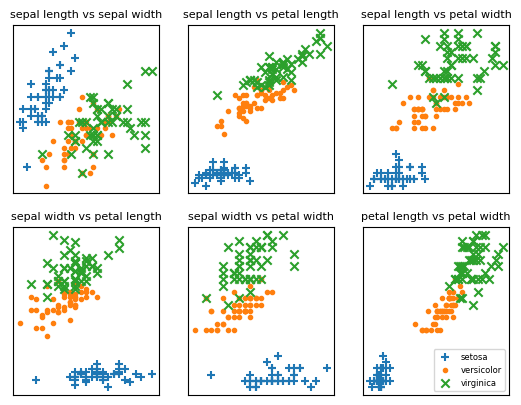

In [9]:
from matplotlib import pyplot as plt
metrics = ["sepal length", "sepal width", "petal length", "petal width"]
pairs = [(i, j) for i in range(4) for j in range(4) if i < j]
marks = ["+", ".", "x"]
# we have 3 classes, so 3 markers
fig, ax = plt.subplots(2, 3)
for row in range(2):
    for col in range(3):
        i, j = pairs[3 * row + col]
        ax[row][col].set_title(f"{metrics[i]} vs {metrics[j]}", fontsize=8)
        ax[row][col].set_xticks([])
        ax[row][col].set_yticks([])
        for mark, (species, points) in zip(marks, points_by_species.items()):
            xs = [point[i] for point in points]
            ys = [point[j] for point in points]
            ax[row][col].scatter(xs, ys, marker=mark, label=species)

ax[-1][-1].legend(loc="lower right", prop={"size": 6})
plt.show()

Si se observa estos gráficos, parece que en realidad las medidas se agrupan por especie. Por ejemplo, mirando solamente la longitud y la anchura del sépalo, probablemente no se podría distinguir entre versicolor y virginica. Pero, en cuanto se añade a la mezcla la longitud y la anchura del pétalo, parece posible predecir la especie basándose en los vecinos más cercanos.     


Para empezar, se va a dividir los datos en un conjunto de prueba y otro de entrenamiento:

In [10]:
import random
from scratch.machine_learning import split_data
random.seed(12)
iris_train, iris_test = split_data(iris_data, 0.70)
assert len(iris_train) == 0.7 * 150
assert len(iris_test) == 0.3 * 150

El conjunto de entrenamiento será los “vecinos” que utilizaremos para clasificar los puntos del conjunto de prueba. Simplemente tenemos que elegir un valor para k, el número de vecinos que consiguen votar.    
Demasiado pequeño (pensemos en k = 1), y dejaremos que los valores atípicos (outliers)tengan demasiada influencia; demasiado grande (digamos k = 105), y simplemente predeciremos la clase más común del conjunto de datos.   

En una aplicación real (y con más datos), podríamos crear un conjunto de validación diferente y emplearlo para elegir k. Aquí utilizaremos k = 5:

In [12]:
from typing import Tuple
# controla las veces que vemos (predicted, actual)
confusion_matrix: Dict[Tuple[str, str], int] = defaultdict(int)
num_correct = 0
for iris in iris_test:
    predicted = knn_classify(5, iris_train, iris.point)
    actual = iris.label
    if predicted == actual:
        num_correct += 1
    confusion_matrix[(predicted, actual)] += 1
pct_correct = num_correct / len(iris_test)
print(pct_correct)
print(confusion_matrix)

0.9777777777777777
defaultdict(<class 'int'>, {('setosa', 'setosa'): 13, ('versicolor', 'versicolor'): 15, ('virginica', 'virginica'): 16, ('virginica', 'versicolor'): 1})


En este sencillo conjunto de datos, el modelo predice casi perfectamente.   

Hay una única versicolor para la que predice virginica, pero por lo demás acierta de pleno.

## La maldición de la dimensionalidad   

El algoritmo de k vecinos más cercanos da problemas con muchas dimensiones gracias a la “maldición de la dimensionalidad”, que se reduce al hecho de que los espacios de muchas dimensiones son inmensos. Los puntos en los espacios con muchas dimensiones tienden a no estar en absoluto cerca unos de otros. 

## Usando la librería **Scikit-Learn**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


### Cargamos el fichero en un dataframe

In [17]:
dataset = pd.read_csv("./iris.data", names=["sepal_length", "sepal_width", "petal_length", "petal_width", "class"])
dataset.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### Separación de características y clase

In [18]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 4].values

### Partición en Train y Test

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4)

### Estandarización    

La estandarización consiste en transformar la distribución de los valores de los atributos para que estos adopten una media y una desviación típica determinadas. Esta transformación se realiza para cada atributo de manera independiente y se calcula restando a cada valor del atributo la media aritmética de los valores originales del atributo y, a continuación, se divide por la desviación típica de estos.  

En esta ocasión, se aplica un escalado en estandarización (mediante la función StandarScaler de la librería SciKit Learn) que para este tipo de algoritmo concreto, va a darse mayor importancia a una característica o a otra según la escala de sus valores. Dicho de otra forma, para este algoritmo, los atributos cuyos valores son más elevados contribuyen más al cálculo de los vecinos que los atributos con valores más bajos. Por tanto, se hace necesario "igualar" las escalas de los atributos previamente a utilizar el algoritmo.

[Ejemplo de escalado de datos](https://interactivechaos.com/es/manual/tutorial-de-machine-learning/escalado-de-datos)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

### Construcción y entrenamiento del modelo

In [22]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=8) # Establecemos 8 como el número de vecinos a tomar
classifier.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",8
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Predicción

In [23]:
y_pred = classifier.predict(X_test)

### Evaluación del modelo K-NN

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("MATRIZ DE CONFUSIÓN")
print(confusion_matrix(y_test, y_pred))

MATRIZ DE CONFUSIÓN
[[20  0  0]
 [ 0 23  0]
 [ 0  2 15]]


In [25]:
print("Accuracy:")
print(accuracy_score(y_test, y_pred))

Accuracy:
0.9666666666666667


In [26]:
print("Informe de métricas")
print(classification_report(y_test, y_pred))

Informe de métricas
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        20
Iris-versicolor       0.92      1.00      0.96        23
 Iris-virginica       1.00      0.88      0.94        17

       accuracy                           0.97        60
      macro avg       0.97      0.96      0.97        60
   weighted avg       0.97      0.97      0.97        60

